# Part 2: K-Means Clustering — Finding Natural Segments
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Wednesday — Customer Segmentation

Yesterday Sarah looked at the data in 2D. Today she finds the actual groups. She wants 3–6 customer segments — enough to be meaningful, few enough to actually act on with NorthStar's marketing team.

K-Means is the standard tool. Three big questions to answer:
1. **What K?** (How many clusters?)
2. **How well do they actually cluster?** (Silhouette score)
3. **What does each cluster MEAN?** (Profiling — naming each one)

**By the end of this notebook you will be able to:**
- Fit K-Means in one line
- Choose K with the elbow method + silhouette score
- Profile each cluster (what makes it distinctive)
- Name your clusters for a non-technical stakeholder

In [11]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — KMeans ready")

✅ Libraries loaded — KMeans ready


## Step 1 — Setup (same preprocessing as NB 02)

In [12]:
df = pd.read_csv("data/northstar_customers.csv")
features = df.drop(columns=["customer_id", "churned"])

numeric_features = ["age", "tenure_months", "num_purchases_quarter",
                    "avg_monthly_spend_gbp", "returns_per_purchase",
                    "last_login_days_ago", "avg_review_polarity",
                    "support_tickets_quarter"]
categorical_features = ["region", "subscription_tier"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_features),
])

X_processed = preprocessor.fit_transform(features)
print(f"Processed shape: {X_processed.shape}")

Processed shape: (10000, 17)


## Step 2 — How to pick K?

K-Means doesn't tell you K. You have to decide. Two standard heuristics:

### 1. Elbow method — Inertia (within-cluster sum of squares)

**Inertia** is the total squared distance from each customer to their assigned cluster centre.

> For every customer: compute the distance to their cluster's centre → square it → sum all of these up.

Lower inertia = tighter clusters. But there's a catch: adding more clusters *always* reduces inertia — at the extreme, K = N gives inertia of zero (each customer is their own cluster of one). So we don't minimise inertia; we look for the **elbow** — the K where adding one more cluster gives diminishing returns on tightness.

### 2. Silhouette score — how well does each customer fit their cluster?

For each customer, the silhouette score compares two things:
- **a** = mean distance to all other customers *in the same cluster* (cohesion — how tight is this cluster?)
- **b** = mean distance to all customers *in the nearest other cluster* (separation — how far from the next-best option?)

$$\text{silhouette} = \frac{b - a}{\max(a, b)}$$

- Score near **+1** → customer is much closer to their own cluster than any other (well-placed)
- Score near **0** → customer sits on the boundary between two clusters (ambiguous)
- Score near **−1** → customer would fit better in a neighbouring cluster (misassigned)

The overall silhouette score is the **mean across all customers**. Higher is better — and unlike inertia, it doesn't always improve with more K. It peaks at the K that best balances cohesion and separation.

We'll compute both for K = 2, 3, ..., 10.

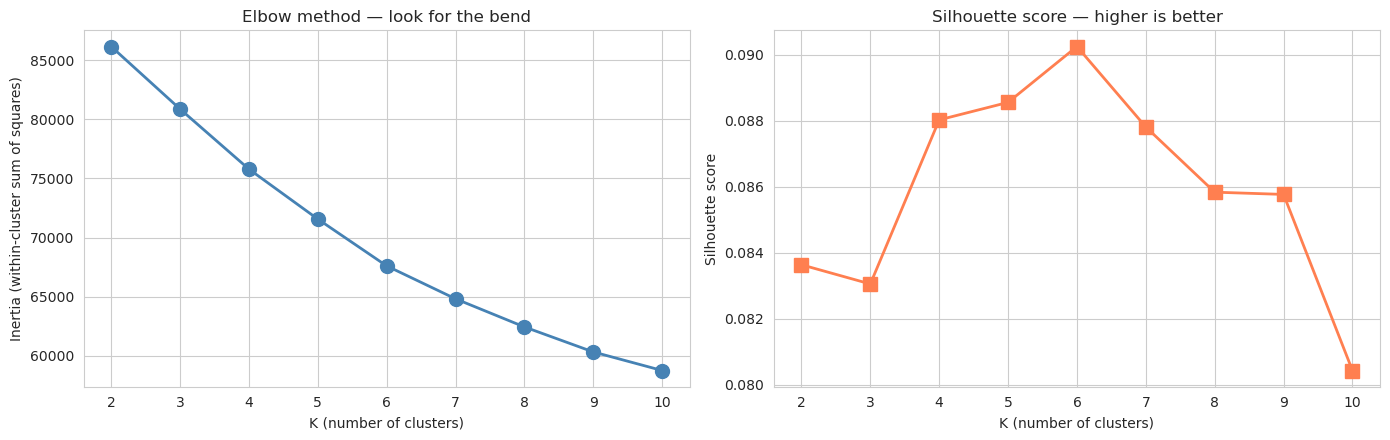

K     Inertia    Silhouette
  2        86155     0.0836
  3        80868     0.0830
  4        75787     0.0880
  5        71564     0.0886
  6        67604     0.0902
  7        64821     0.0878
  8        62444     0.0858
  9        60330     0.0858
  10        58760     0.0804


In [13]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(K_range, inertias, "o-", linewidth=2, color="steelblue", markersize=10)
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method — look for the bend")

axes[1].plot(K_range, silhouettes, "s-", linewidth=2, color="coral", markersize=10)
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score — higher is better")

plt.tight_layout()
plt.show()

print("K     Inertia    Silhouette")
for k, inertia, sil in zip(K_range, inertias, silhouettes):
    print(f"  {k}   {inertia:10.0f}     {sil:.4f}")

**<span style="color:green">[Opus 4.8]</span> Cluster-quality metrics, in depth:**

Two families of metrics drive the choice of K. Their precise definitions, and how to read the (deliberately low) numbers printed above:

**Inertia — within-cluster sum of squares (the objective K-Means minimises).**

$$\text{Inertia}=\sum_{i=1}^{N}\lVert x_i-\mu_{c(i)}\rVert^{2}$$

Each customer's squared distance to *its own* cluster centroid $\mu_{c(i)}$, summed over all $N$ customers. It only ever **decreases** as K grows (at K = N every point is its own centroid and inertia = 0), so it is never minimised directly — the **elbow** is the K where the marginal drop flattens. The raw figure (75,787 at K = 4) is in squared-distance units of the 17-D scaled space and is meaningful only relative to other K on the same data.

**Silhouette — a per-customer fit score, then averaged.**

For customer $i$: $a(i)$ = mean distance to the other points in *its own* cluster (cohesion); $b(i)$ = mean distance to the **nearest other** cluster (separation).

$$s(i)=\frac{b(i)-a(i)}{\max\!\big(a(i),\,b(i)\big)}\in[-1,\,1]$$

The reported score is the mean of $s(i)$ over all customers. Unlike inertia it peaks at an intermediate K (here K = 6, 0.0902). **Read the magnitude, not just the peak:** silhouette ranges to 1.0, so values around **0.09 are low** — they confirm NB 02's finding that these customers form one diffuse, overlapping cloud rather than crisp islands. The near-tie across K (0.083–0.090) means *no* K is statistically compelling, which is precisely why the decision in Step 3 falls to business judgement.

**Other metrics you will encounter:**
- **Adjusted Rand Index** (`adjusted_rand_score`, used in Extension 1) — not a quality score for a single clustering but a chance-corrected *agreement* score between two labelings: 1 = identical partitions, 0 = random overlap. Use it to compare runs or seeds, not to choose K.
- **Davies–Bouldin** (lower is better) and **Calinski–Harabasz** (higher is better) — variance-ratio alternatives in `sklearn.metrics`, useful as a second opinion when silhouette is as ambiguous as it is here.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

## ⏸️ Pause and Predict

Look at the elbow plot and silhouette plot. Before reading on, decide:
- What K would you pick?
- What would you tell Marcus if he asked WHY?

*Your prediction:*

> *Hints to consider:*
> - The elbow plot's "bend" is rarely sharp on real data. Often it's a smooth curve — look for where the slope starts to flatten.
> - Silhouette score peaks at SOME K — check the printed table to find which K scores highest. That's the statistical vote.
> - **Business judgement matters.** The silhouette-optimal K is not always the most *actionable* K. A very high K (e.g. 8–10) segments customers finely but multiplies operational complexity — six different email tracks, six sets of offers. A very low K (e.g. 2) is easy to brief but too coarse to be useful. Sweet spot for most business contexts: **3–5 segments**.

## Step 3 — Pick K = 4

We'll commit to **K = 4**.

From the printed table, silhouette peaks at **K = 6** (score 0.0902). So why not K = 6?

| Consideration | K = 6 | K = 4 |
|---|---|---|
| **Silhouette score** | 0.0902 ✓ (best) | 0.0880 (close) |
| **Statistical signal** | Marginally tighter clusters | Nearly identical quality |
| **Operational cost** | 6 email tracks, 6 offer sets, 6 slide rows | 4 — manageable for one marketing team |
| **Presentation clarity** | Hard to name 6 distinct segments crisply | 4 clear names fit on a slide |

The score difference between K=4 and K=6 is 0.002 — essentially noise at this dataset size. The business cost of 6 segments over 4 is real. **We pick K = 4.**

> **The general rule:** optimise for the smallest K that still gives meaningfully different segments, and that a non-technical stakeholder can act on. Here, K = 4 meets that bar.

**<span style="color:green">[Opus 4.8]</span> Choosing the number of segments — the trade-off in full:**

The 0.002 silhouette gap between K = 4 and K = 6 is noise at $n = 10{,}000$, so this is genuinely a business decision rather than a statistical one. Two forces push toward *fewer* clusters:

- **Operational cost.** Every segment becomes an artefact the marketing team must *operate*: its own email track, offer set, creative, landing page and reporting line. Six segments is 50% more campaign machinery than four, for a single team — a recurring cost the model's 0.002 gain cannot justify.
- **Presentation clarity.** A segment is only useful if it has one distinct, actionable identity. As K rises, K-Means subdivides existing groups along progressively *weaker secondary signals*, so the marginal clusters differ only subtly and resist a clean one-line name — and stakeholders cannot hold six personas in mind at once.

**The counter-consideration — do not treat K = 4 as automatically correct.** Coarsening to four clusters here *hides two of the most distinctive groups*. At K = 6 the profile cleanly separates a **high-spend** segment (`avg_monthly_spend_gbp` ≈ £224 vs £70 globally, ~660 customers) and a **dormant** segment (`last_login_days_ago` ≈ 94 vs 30). Folding those into broader clusters dilutes a group spending **3× the average** — often the single most commercially valuable thing a segmentation can surface. The professional move is to *name this trade-off explicitly*: choose the smaller K for operability, but flag that a high-value niche exists and may deserve its own treatment regardless of the headline segmentation.

**Rule of thumb:** pick the smallest K whose segments are *meaningfully different and individually actionable*, then sanity-check that no high-value micro-segment is being averaged away at that resolution.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

In [23]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(X_processed)

# Add cluster labels to the original dataframe (with raw features)
df_clustered = features.copy()
df_clustered["cluster"] = labels

# Cluster sizes
print(f"K = {K}")
print()
print("Cluster sizes:")
print(df_clustered["cluster"].value_counts().sort_index().to_string())

K = 4

Cluster sizes:
cluster
0    3463
1    1138
2    3540
3    1859


## Step 4 — Visualise clusters in PCA space

Project to 2D with PCA (from NB 02) and colour by cluster. This is the picture Sarah will put on the Friday slides.

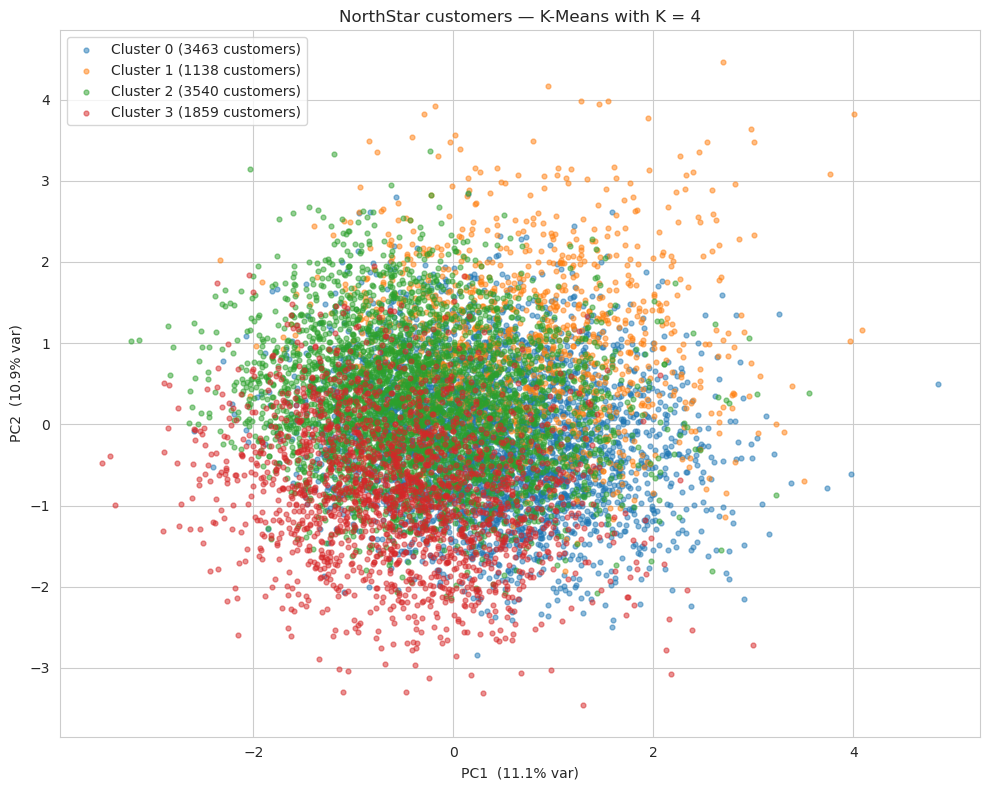

In [24]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_processed)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728"]
for c in range(K):
    mask = labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                alpha=0.5, s=12, color=colors[c],
                label=f"Cluster {c} ({mask.sum()} customers)")
ax.set_xlabel(f"PC1  ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2  ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"NorthStar customers — K-Means with K = {K}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### 💡 What you should notice

- The clusters are **visible in PCA space**, even though the 2D coloured cloud wasn't obviously separable in NB 02.
- K-Means is using ALL 17 dimensions to find the groups — the 2D plot is just a projection of that result.
- Some overlap is normal. K-Means assigns every customer to exactly ONE cluster (hard assignment) — there are no "in-between" customers.

**<span style="color:green">[Opus 4.8]</span> What the PCA-coloured scatter does — and does not — show:**

This plot is a **diagnostic projection**, not the clustering itself. K-Means assigned each customer using all **17** standardised dimensions; the scatter then flattens those 17-D points onto the two PCA axes from NB 02 and colours them by that assignment. Three consequences:

- **Bands of colour** indicate the clusters occupy distinguishable regions of the *highest-variance* plane — encouraging, but only a partial view.
- **Overlap between colours is expected, not a failure.** PC1 and PC2 together carry only ~22% of the total variance (NB 02), so two customers can sit on top of each other *here* yet be far apart in the 15 dimensions the plot cannot display. The separation K-Means actually used lives in the full space — never judge cluster quality from this 2-D shadow; that is what the silhouette score is for.
- **Hard assignment.** Every point receives exactly one colour. K-Means has no "between clusters" state, even for a customer sitting on a boundary.

> **Implementation note:** the `colors` list here holds exactly K = 4 entries, one per cluster. If you experiment with a larger K, extend this palette to match — `colors[c]` will otherwise raise `IndexError` for clusters beyond the fourth.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

## Step 5 — Cluster profiles: what makes each cluster distinctive?

For each cluster, compute the mean of every feature. Compare to the global mean to spot what each cluster is about.

In [22]:
# Profile each cluster on the ORIGINAL (unscaled) numeric features
numeric_cols = ["age", "tenure_months", "num_purchases_quarter",
                "avg_monthly_spend_gbp", "returns_per_purchase",
                "last_login_days_ago", "avg_review_polarity",
                "support_tickets_quarter"]

profile = df_clustered.groupby("cluster")[numeric_cols].mean().round(2)
global_mean = features[numeric_cols].mean().round(2)
profile.loc["GLOBAL_MEAN"] = global_mean

print("Cluster profiles vs global mean:")
print(profile.to_string())

Cluster profiles vs global mean:
               age  tenure_months  num_purchases_quarter  avg_monthly_spend_gbp  returns_per_purchase  last_login_days_ago  avg_review_polarity  support_tickets_quarter
cluster                                                                                                                                                                 
0            32.00          33.92                   6.31                  56.08                  0.10                21.52                 0.19                     0.76
1            48.65          36.26                   5.87                  60.04                  0.33                22.54                 0.18                     0.97
2            49.48          38.93                   5.96                  60.58                  0.11                22.77                 0.10                     2.83
3            66.39          34.47                   5.78                  59.49                  0.10                20.98

## Step 6 — Heatmap of standardised differences

A heatmap makes the "what's different" pattern visible at a glance. Standardise each cluster's mean by subtracting the global mean and dividing by the global standard deviation.

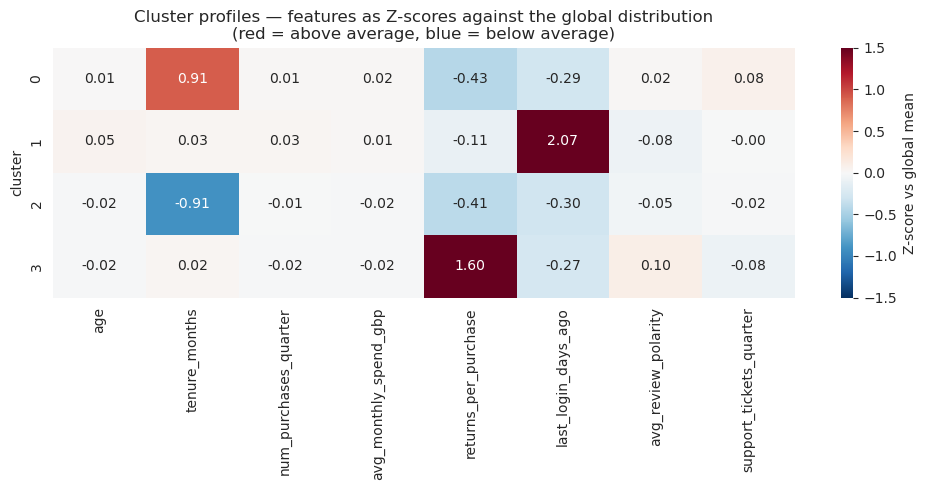

In [17]:
# Z-score each cluster's mean against the global distribution
global_std  = features[numeric_cols].std()
cluster_means = df_clustered.groupby("cluster")[numeric_cols].mean()
z_scores = (cluster_means - global_mean) / global_std

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(z_scores, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1.5, vmax=1.5, cbar_kws={"label": "Z-score vs global mean"}, ax=ax)
ax.set_title(f"Cluster profiles — features as Z-scores against the global distribution\n(red = above average, blue = below average)")
plt.tight_layout()
plt.show()

### 💡 What this tells us — naming the clusters

Each row of the heatmap has one or two dominant colours. That's the signal. Everything else is noise.

| Cluster | Size | Dominant signals | Name |
|---|---|---|---|
| **0** | 3,463 (35%) | `tenure_months` +0.91 ↑, `returns` −0.43 ↓, `last_login` −0.29 ↓ | **"Loyal Veterans"** |
| **1** | 1,138 (11%) | `last_login_days_ago` +2.07 ↑↑ (everything else average) | **"Dormant / At-Risk"** |
| **2** | 3,540 (35%) | `tenure_months` −0.91 ↓, `returns` −0.41 ↓, `last_login` −0.30 ↓ | **"New Actives"** |
| **3** | 1,859 (19%) | `returns_per_purchase` +1.60 ↑↑ (everything else average) | **"Serial Returners"** |

**Reading each cluster:**

- **Cluster 0 — "Loyal Veterans"** (35% of base): Long-tenured, few returns, recently logged in. The healthiest segment. Prime candidates for loyalty rewards or a premium upsell campaign.

- **Cluster 1 — "Dormant / At-Risk"** (11% of base): Average on almost every feature — but they haven't logged in for a very long time (last login +2.07 SD above the mean). They look fine on paper; they're silently churning. Top priority for a re-engagement campaign.

- **Cluster 2 — "New Actives"** (35% of base): New customers (short tenure) who are nonetheless recently active and returning little. They're engaged and finding what they want. Onboarding, early loyalty incentives, and cross-sell are the right plays.

- **Cluster 3 — "Serial Returners"** (19% of base): Return rate is the single defining feature — dramatically above average (+1.60 SD). Everything else is unremarkable. This could be size/fit issues, expectation mismatches, or opportunistic buy-return behaviour. Worth a product team conversation before running any promotions on this group.

**Key insight:** The clearest signals in this dataset are *tenure*, *login recency*, and *return rate* — not spend or age. That's what the data is telling Sarah and Marcus to act on.

**<span style="color:green">[Opus 4.8]</span> What K-Means computes vs. what profiling and naming add:**

These three stages are routinely conflated; keeping them separate is what lets you explain a segmentation defensibly.

1. **K-Means (the algorithm)** does exactly two things, both in the scaled 17-D space: it **assigns** every customer to one of K clusters (hard assignment) and maintains the K **centroids** (each cluster's mean position), iterating assign ↔ recompute until stable. Its entire output is a vector of integer labels (`0 … K−1`) plus those centroids. It has no concept of "returns" or "loyalty" — only geometry.
2. **Profiling (Steps 5–6)** is analyst code layered *on top* of the labels: group customers by cluster, average the **original, unscaled** features, then z-score each cluster mean against the global mean and SD so the heatmap reads as "how many standard deviations from typical." None of this is part of K-Means — it is how we *interpret* the partition.
3. **Naming** is human judgement: read each heatmap row's dominant ±signals and attach a business label. The model cannot do this step; it is where domain knowledge enters and where the value is created.

So the heatmap is **not** "K-Means internal work." The algorithm produces the split; profiling *measures* each piece; naming *gives it meaning*. The very same labels could be profiled and named differently depending on the business question being asked.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

## ✅ Section Summary

| What we did | Output |
|---|---|
| **Computed elbow + silhouette** for K = 2-10 | Two metrics for choosing K |
| **Picked K = 4** | Business judgement — actionable number of segments |
| **Fit K-Means** | 4 cluster labels, one per customer |
| **Plotted in PCA space** | Visible groupings even when raw 2D wasn't obvious |
| **Profiled each cluster** | Per-cluster feature means + heatmap of Z-score differences |
| **Named the segments** | The output Marcus actually wants — meaningful labels, not numbers |

**Key insight for our scenario:**
> K-Means alone gives Sarah numbers (cluster 0, 1, 2, 3). The VALUE comes from profiling — translating "cluster 2" into "Loyal high-value customers, 26% of base, candidates for the premium upsell campaign."

---
**Up next → Part 3:** Thursday — Isolation Forest for anomaly detection. Find unusual customers worth investigating.
Open `04_isolation_forest.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Reproducibility: K-Means and random_state

K-Means starts from random initial centroids. With `n_init=10` (default), it tries 10 different starting points and keeps the best. But two runs with different `random_state` can still give slightly different cluster ASSIGNMENTS — even if the clusters themselves are very similar.

ALWAYS set `random_state` for reproducible work.

In [18]:
# Compare K-Means with two different random_states
km_42  = KMeans(n_clusters=4, random_state=42, n_init=10)
km_123 = KMeans(n_clusters=4, random_state=123, n_init=10)

labels_42  = km_42.fit_predict(X_processed)
labels_123 = km_123.fit_predict(X_processed)

# Cluster sizes
sizes_42  = pd.Series(labels_42).value_counts().sort_index().values
sizes_123 = pd.Series(labels_123).value_counts().sort_index().values

print(f"Cluster sizes with random_state=42:   {sizes_42}")
print(f"Cluster sizes with random_state=123:  {sizes_123}")

# Pairwise agreement — what fraction of customers got the SAME cluster?
# (Note: cluster IDs might be permuted between the two runs. Best to use ARI.)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels_42, labels_123)
print()
print(f"Adjusted Rand Index between the two runs: {ari:.3f}")
print("→ ARI ≈ 1 means same clustering. ARI ≈ 0 means random agreement.")
print("→ K-Means is usually stable on tabular data; random_state matters mostly for getting EXACT reproducibility.")

Cluster sizes with random_state=42:   [3463 1138 3540 1859]
Cluster sizes with random_state=123:  [3908  856 1218 4018]

Adjusted Rand Index between the two runs: 0.569
→ ARI ≈ 1 means same clustering. ARI ≈ 0 means random agreement.
→ K-Means is usually stable on tabular data; random_state matters mostly for getting EXACT reproducibility.


**<span style="color:green">[Opus 4.8]</span> Reproducibility: seeds, `n_init`, and reading ARI = 0.569 honestly:**

- **`random_state` is about reproducibility, not correctness — and 42 is arbitrary.** It only fixes the random initial centroids so a rerun is byte-identical. The number itself is a programmer convention (a *Hitchhiker's Guide* in-joke); any fixed integer is equally valid. The actionable rule is *pin one value and record it* — not "use 42." Different seeds are not "wrong"; they are simply different valid starting points.
- **`n_init`** is the number of independent random starts K-Means tries before keeping the lowest-inertia result; more starts = more robust to an unlucky initialisation. The code sets `n_init=10` explicitly, which is now the correct habit: **since scikit-learn 1.4 the default is `n_init='auto'`, not 10**, so relying on "the default is 10" is out of date.
- **What ARI = 0.569 actually tells us.** The two seeds produce visibly different partitions (sizes 3463 / 1138 / 3540 / 1859 vs 3908 / 856 / 1218 / 4018) and only *moderate* agreement (ARI = 1.0 means identical, 0 means chance). That tempers the "usually stable" framing: on this dataset — whose clusters genuinely overlap (silhouette ≈ 0.09) — the solution is **seed-sensitive**, so pinning `random_state` matters *more*, not less. If you need a partition you can defend as robust, raise `n_init` (e.g. 25–50) and report the silhouette, rather than trusting a single seed.

**Takeaway:** reproducibility (fix the seed) and stability (the clustering barely changes across seeds) are *different* properties. This notebook achieves the first; its own ARI shows it only partly has the second.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

## Extension 2 — When K-Means struggles: non-globular clusters

K-Means assumes clusters are SPHERICAL (roughly equal in all directions). When the natural clusters are elongated, stringy, or irregularly shaped, K-Means fails — it carves up the natural shapes into pieces.

For non-globular structure, use **DBSCAN** (density-based) — covered in `optional_extensions.ipynb`.

For now, here's a synthetic demo to make the limitation visible.

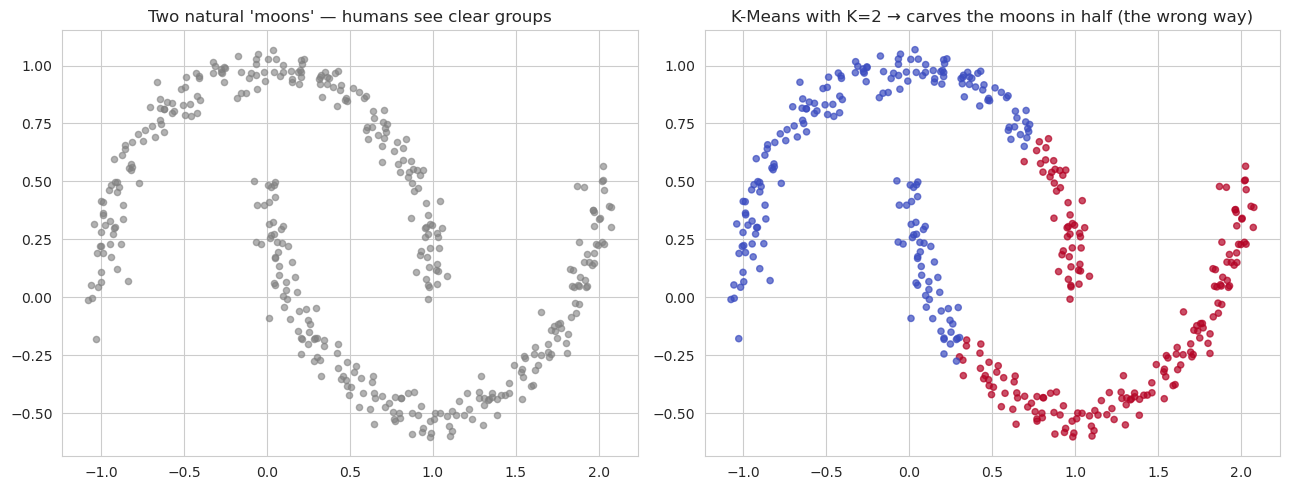

→ K-Means fails on non-globular shapes. Use DBSCAN if you suspect this.


In [19]:
from sklearn.datasets import make_moons

# Two interlocking moons — clearly two groups, but not spherical
X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42)

km_demo = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_demo = km_demo.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], s=20, color="gray", alpha=0.6)
axes[0].set_title("Two natural 'moons' — humans see clear groups")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_demo, cmap="coolwarm", s=20, alpha=0.7)
axes[1].set_title("K-Means with K=2 → carves the moons in half (the wrong way)")

plt.tight_layout()
plt.show()
print("→ K-Means fails on non-globular shapes. Use DBSCAN if you suspect this.")

**<span style="color:green">[Opus 4.8]</span> DBSCAN vs K-Means — density-based clustering, and when to switch:**

The moons demo exposes K-Means' core assumption: it builds **spherical** clusters around centroids, so it slices each crescent straight through rather than following its shape. **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) starts from a different premise — it grows clusters through **dense regions** and leaves sparse points unassigned.

- **`eps`** sets the neighbourhood radius; **`min_samples`** sets how many points must fall within `eps` for a point to be a dense **core** point. Clusters form by chaining core points through their overlapping neighbourhoods; any point reachable from no core is labelled **noise** (`−1`).

| | **K-Means** | **DBSCAN** |
|---|---|---|
| Cluster shape | spherical / globular only | arbitrary (moons, rings, strings) |
| Number of clusters | you must specify K | discovered from the data's density |
| Outliers | every point forced into a cluster | isolated points become noise (`−1`) |
| Main parameters | `n_clusters`, `n_init`, `random_state` | `eps`, `min_samples` |
| Scales to large / high-dim | well | less well; a single `eps` is hard to set in high dimensions |
| Typical failure mode | non-globular shapes (this demo) | clusters of very different density |

**Choosing between them:** globular groups and you need speed/scale → K-Means; irregular shapes, an unknown cluster count, or a need to *flag outliers explicitly* → DBSCAN. Note the contrast in philosophy — K-Means **partitions** every customer; DBSCAN is willing to say "this point belongs to no cluster," which is often exactly what you want for anomaly-style questions (a theme NB 04 picks up). A worked DBSCAN example lives in `optional_extensions.ipynb`.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**

## Extension 3 — Mini-batch K-Means for large datasets

For very large datasets (>100k rows), regular K-Means is slow. `MiniBatchKMeans` uses random subsets each iteration — much faster, almost as accurate.

In [20]:
from sklearn.cluster import MiniBatchKMeans
import time

# Time regular vs mini-batch
start = time.time()
km_full = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_processed)
t_full = time.time() - start

start = time.time()
km_mini = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=512, n_init=10).fit(X_processed)
t_mini = time.time() - start

# Compare cluster qualities
sil_full = silhouette_score(X_processed, km_full.labels_)
sil_mini = silhouette_score(X_processed, km_mini.labels_)

print(f"Full KMeans:    time = {t_full*1000:.0f}ms, silhouette = {sil_full:.4f}")
print(f"MiniBatch:      time = {t_mini*1000:.0f}ms, silhouette = {sil_mini:.4f}")
print()
print("MiniBatchKMeans is the right choice when full KMeans takes >10s.")
print("For our 10k-row dataset, the difference is small. For 1M+ rows it's enormous.")

Full KMeans:    time = 569ms, silhouette = 0.0880
MiniBatch:      time = 91ms, silhouette = 0.0771

MiniBatchKMeans is the right choice when full KMeans takes >10s.
For our 10k-row dataset, the difference is small. For 1M+ rows it's enormous.


**<span style="color:green">[Opus 4.8]</span> MiniBatchKMeans — how it buys speed, and what it costs:**

Standard K-Means recomputes its centroids from **all** rows on every iteration — accurate, but the per-iteration cost grows with the dataset. **MiniBatchKMeans** instead samples a small random **mini-batch** (`batch_size=512` here) each step and nudges the centroids toward just that subset. Far less work per iteration, so it converges much faster, at the price of slightly noisier, approximate centroids.

The run above quantifies the trade: **≈ 569 ms → ≈ 91 ms (~6× faster)** while silhouette slips **0.0880 → 0.0771**. At 10k rows the speedup is immaterial and full K-Means is preferable for the cleaner result; the technique earns its place at roughly **$10^5$–$10^6$+ rows**, on streaming data, or when the full matrix will not fit in memory — there the time saving is decisive and the small quality drop is acceptable.

**Practical guidance:** reach for MiniBatchKMeans when full K-Means takes more than ~10 s or exhausts memory; otherwise prefer full K-Means. `batch_size` is the main lever — larger batches track full K-Means more closely but cost more per step; smaller batches are faster but noisier. As always, keep `random_state` fixed and `n_init` explicit for reproducibility.

**<span style="color:green"><em>[Opus 4.8] — end of note</em></span>**